In [ ]:
%pip install --upgrade "plotly>=6.1" "kaleido>=1"

from pathlib import Path

import pandas as pd
import plotly.express as px

# Load NAV history dataset
search_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
csv_path = next(
    (
        path
        for root in search_roots
        for path in root.rglob("02_nav_history.csv")
        if path.is_file()
    ),
    None,
)

if csv_path is None:
    raise FileNotFoundError(
        "02_nav_history.csv was not found. Place it in the project folder."
    )

nav_history = pd.read_csv(csv_path)

# Ensure date column is datetime format
nav_history['date'] = pd.to_datetime(nav_history['date'])

# Filter or select schemes if needed (plotting all or a subset for performance)
nav_history["amfi_code"] = nav_history["amfi_code"].astype(str)

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    labels={"amfi_code": "AMFI Code"},
)

# Export chart for final report
Path("exports").mkdir(parents=True, exist_ok=True)

# Highlight 2023 bull run and 2024 market corrections
fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31", 
    fillcolor="green", opacity=0.15, layer="below", line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01", x1="2024-12-31", 
    fillcolor="red", opacity=0.15, layer="below", line_width=0,
    annotation_text="2024 Market Corrections", annotation_position="top left"
)

fig.update_layout(xaxis_title='Date', yaxis_title='NAV (₹)', template='plotly_white')
fig.show()

# Export chart for final report
#fig.write_image("exports/nav_trend.png", engine="kaleido")

Note: you may need to restart the kernel to use updated packages.


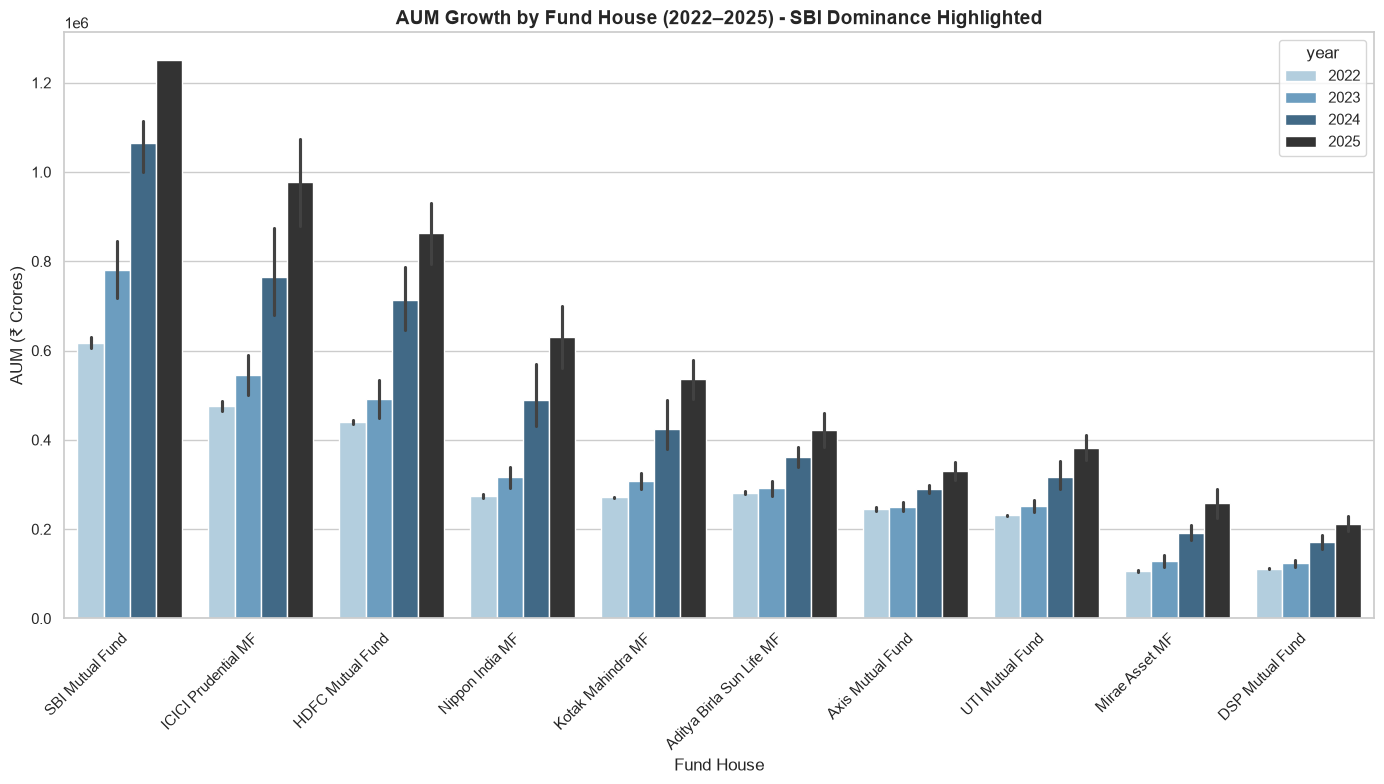

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Load AUM dataset
aum_path = next(
	(
		path
		for root in search_roots
		for path in root.rglob("03_aum_by_fund_house.csv")
		if path.is_file()
	),
	None,
)

if aum_path is None:
	raise FileNotFoundError(
		"03_aum_by_fund_house.csv was not found in the project folders."
	)

aum_data = pd.read_csv(aum_path)

# Create exports directory if not exists
Path("exports").mkdir(parents=True, exist_ok=True)

# Prepare date and year columns for plotting
aum_data['date'] = pd.to_datetime(aum_data['date'])
aum_data['year'] = aum_data['date'].dt.year

# Set figure size and style
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Grouped bar chart for AUM growth by fund house (2022-2025)
ax = sns.barplot(
	data=aum_data,
	x='fund_house',
	y='aum_crore',
	hue='year',
	palette='Blues_d',
)

# Highlight SBI at ₹12.5L Cr dominance
plt.title('AUM Growth by Fund House (2022–2025) - SBI Dominance Highlighted', fontsize=14, weight='bold')
plt.xlabel('Fund House', fontsize=12)
plt.ylabel('AUM (₹ Crores)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Export chart directly without kaleido error
plt.tight_layout()
plt.savefig("exports/aum_growth.png", dpi=300)
plt.show()

In [15]:
import pandas as pd
import plotly.express as px

# Load monthly SIP inflows dataset (using exact workspace file name)
sip_path = next(
    (
        path
        for root in search_roots
        for path in root.rglob("04_monthly_sip_inflows.csv")
        if path.is_file()
    ),
    None,
)

if sip_path is None:
    raise FileNotFoundError(
        "04_monthly_sip_inflows.csv was not found in the project folders."
    )

sip_data = pd.read_csv(sip_path)

# Ensure month column is datetime
sip_data['month'] = pd.to_datetime(sip_data['month'])

# Create line chart for monthly SIP trend
fig_sip = px.line(
    sip_data,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows Trend (Jan 2022 – Dec 2025)',
    labels={'sip_inflow_crore': 'SIP Inflow (₹ Crores)', 'month': 'Month'}
)

# Annotate the ₹31,002 Cr all-time high in Dec 2025
fig_sip.add_annotation(
    x='2025-12-01',
    y=31002,
    text="All-Time High: ₹31,002 Cr (Dec 2025)",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="red",
    ax=-50,
    ay=-50
)

fig_sip.update_layout(template='plotly_white')
fig_sip.show()

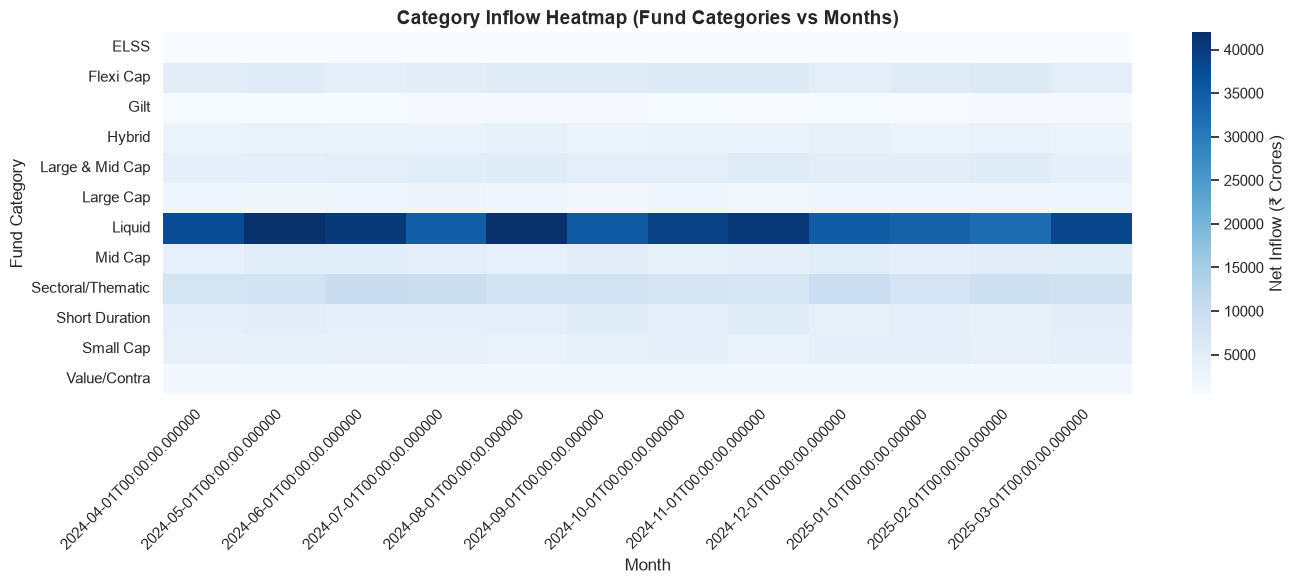

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load category inflows dataset
category_inflows_path = next(
	(
		path
		for root in search_roots
		for path in root.rglob("05_category_inflows.csv")
		if path.is_file()
	),
	None,
)

if category_inflows_path is None:
	raise FileNotFoundError(
		"05_category_inflows.csv was not found in the project folders."
	)

category_inflows = pd.read_csv(category_inflows_path)

# Pivot data to form a matrix (Categories vs Months)
category_inflows["month"] = pd.to_datetime(category_inflows["month"])

pivot_inflows = category_inflows.pivot_table(
	index="category",
	columns="month",
	values="net_inflow_crore",
	aggfunc="sum",
)

# Set figure size and generate heatmap
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")
sns.heatmap(pivot_inflows, annot=False, cmap='Blues', fmt='.1f', cbar_kws={'label': 'Net Inflow (₹ Crores)'})

plt.title('Category Inflow Heatmap (Fund Categories vs Months)', fontsize=14, weight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Fund Category', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Save and show
plt.tight_layout()
plt.savefig("exports/category_heatmap.png", dpi=300)
plt.show()

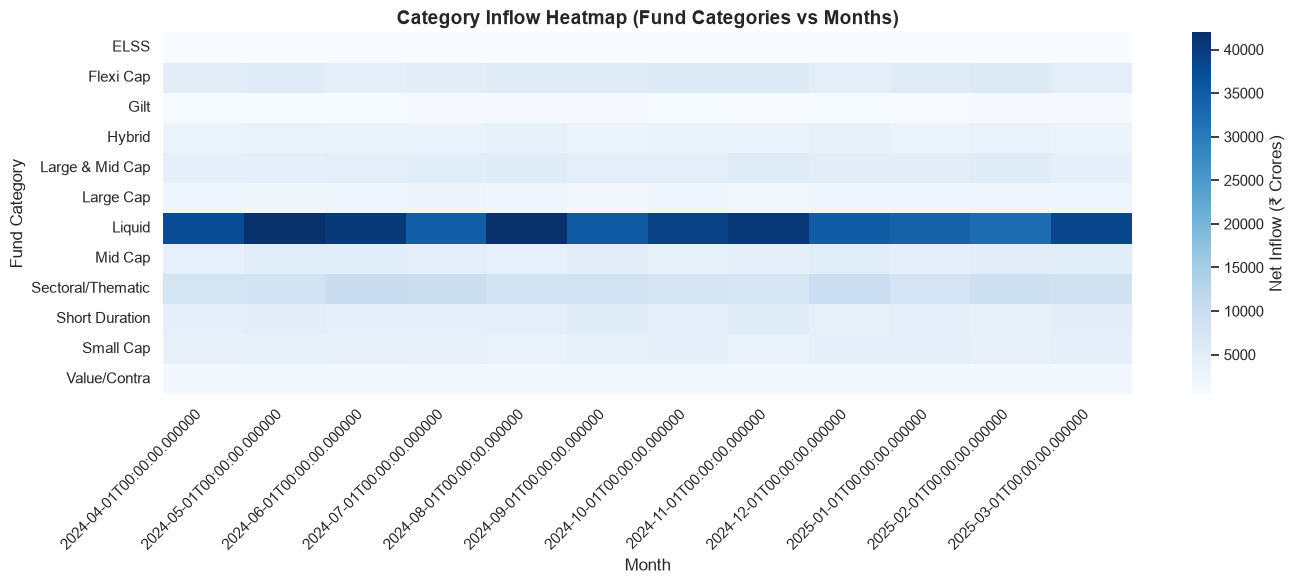

In [19]:
# Load category inflows dataset
if category_inflows_path is None:
	raise FileNotFoundError(
		"05_category_inflows.csv was not found in the project folders."
	)

category_inflows = pd.read_csv(category_inflows_path)
category_inflows["month"] = pd.to_datetime(category_inflows["month"])

# Pivot data to form a matrix (Categories vs Months)
pivot_inflows = category_inflows.pivot(
	index="category",
	columns="month",
	values="net_inflow_crore",
)

# Set figure size and generate heatmap
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")
sns.heatmap(
	pivot_inflows,
	annot=False,
	cmap="Blues",
	fmt=".1f",
	cbar_kws={"label": "Net Inflow (₹ Crores)"},
)

plt.title("Category Inflow Heatmap (Fund Categories vs Months)", fontsize=14, weight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Fund Category", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Save and show
plt.tight_layout()
plt.savefig("exports/category_heatmap.png", dpi=300)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_2448\2652876933.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_sip, x='amount_inr', y='state', ax=axes[0], palette='Blues_r')


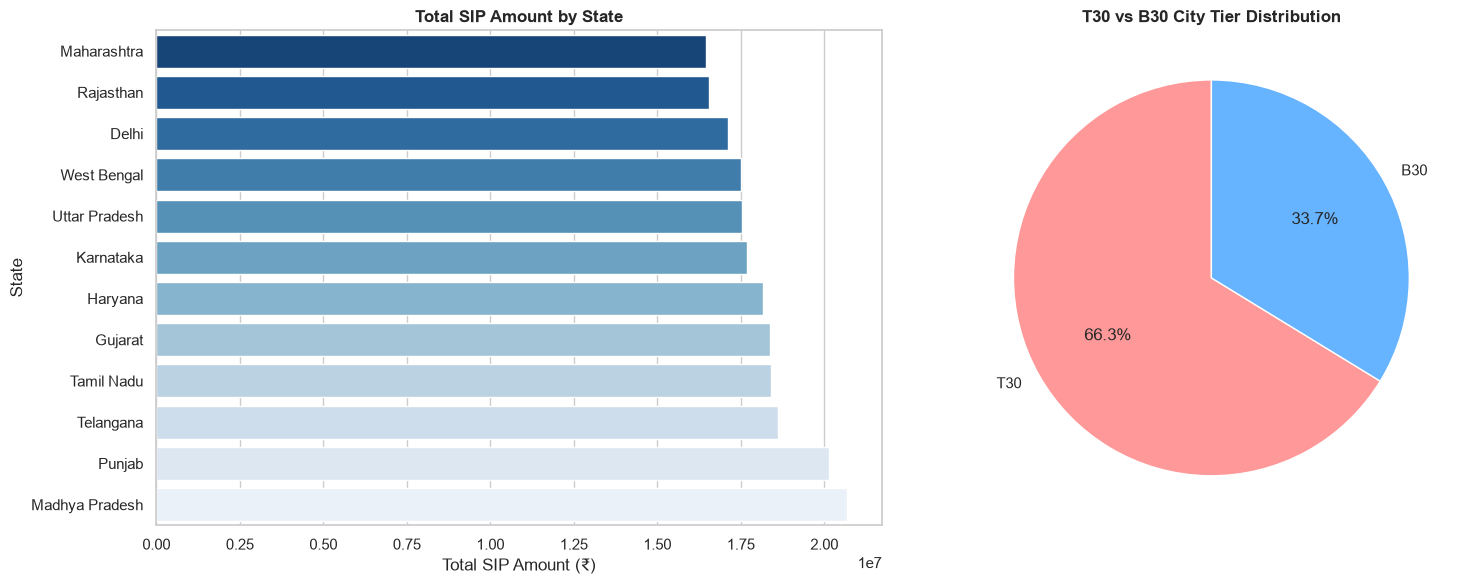

In [22]:
# Load investor transactions dataset (contains state and city_tier columns)
investor_txns_path = next(
	(
		path
		for root in search_roots
		for path in root.rglob("08_investor_transactions.csv")
		if path.is_file()
	),
	None,
)

if investor_txns_path is None:
	raise FileNotFoundError(
		"08_investor_transactions.csv was not found in the project folders."
	)

investor_txns = pd.read_csv(investor_txns_path)

# Set up subplots for Geographic Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# 1. Horizontal bar chart of SIP amount by state
state_sip = (
	investor_txns[investor_txns['transaction_type'] == 'SIP']
	.groupby('state')['amount_inr']
	.sum()
	.reset_index()
	.sort_values(by='amount_inr', ascending=True)
)
sns.barplot(data=state_sip, x='amount_inr', y='state', ax=axes[0], palette='Blues_r')
axes[0].set_title('Total SIP Amount by State', fontsize=12, weight='bold')
axes[0].set_xlabel('Total SIP Amount (₹)')
axes[0].set_ylabel('State')

# 2. T30 vs B30 city tier pie chart
tier_counts = investor_txns['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
axes[1].set_title('T30 vs B30 City Tier Distribution', fontsize=12, weight='bold')

plt.tight_layout()
plt.savefig("exports/geographic_distribution.png", dpi=300)
plt.show()

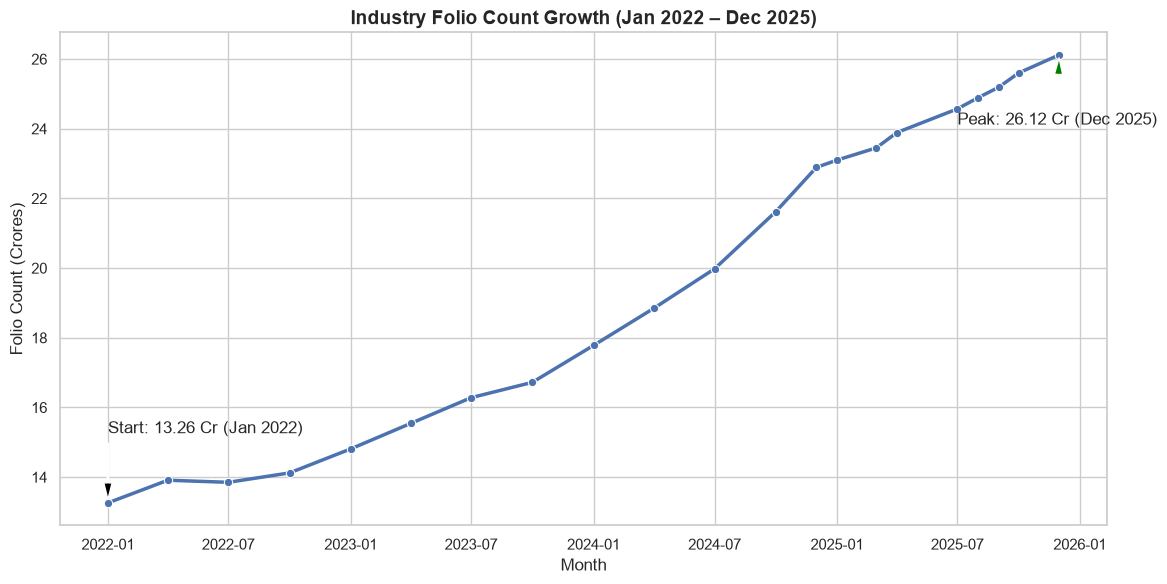

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load industry folio count dataset
folio_path = next(
    (
        path
        for root in search_roots
        for path in root.rglob("06_industry_folio_count.csv")
        if path.is_file()
    ),
    None,
)

if folio_path is None:
    raise FileNotFoundError(
        "06_industry_folio_count.csv was not found in the project folders."
    )

folio_df = pd.read_csv(folio_path)

# Ensure month column is datetime
folio_df["month"] = pd.to_datetime(folio_df["month"], format="%Y-%m")
folio_df = folio_df.sort_values("month").reset_index(drop=True)

# Set figure size and style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot folio count growth line chart
sns.lineplot(
    data=folio_df,
    x="month",
    y="total_folios_crore",
    marker="o",
    color="b",
    linewidth=2.5,
)

plt.title("Industry Folio Count Growth (Jan 2022 – Dec 2025)", fontsize=14, weight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Folio Count (Crores)", fontsize=12)

# Annotate key milestones (Start and End / Peak milestones)
plt.annotate(
    "Start: 13.26 Cr (Jan 2022)",
    xy=(folio_df["month"].iloc[0], folio_df["total_folios_crore"].iloc[0]),
    xytext=(folio_df["month"].iloc[0], folio_df["total_folios_crore"].iloc[0] + 2),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=6),
)

plt.annotate(
    "Peak: 26.12 Cr (Dec 2025)",
    xy=(folio_df["month"].iloc[-1], folio_df["total_folios_crore"].iloc[-1]),
    xytext=(folio_df["month"].iloc[-5], folio_df["total_folios_crore"].iloc[-1] - 2),
    arrowprops=dict(facecolor="green", shrink=0.05, width=1, headwidth=6),
)

plt.tight_layout()
plt.savefig("exports/folio_count_growth.png", dpi=300)
plt.show()

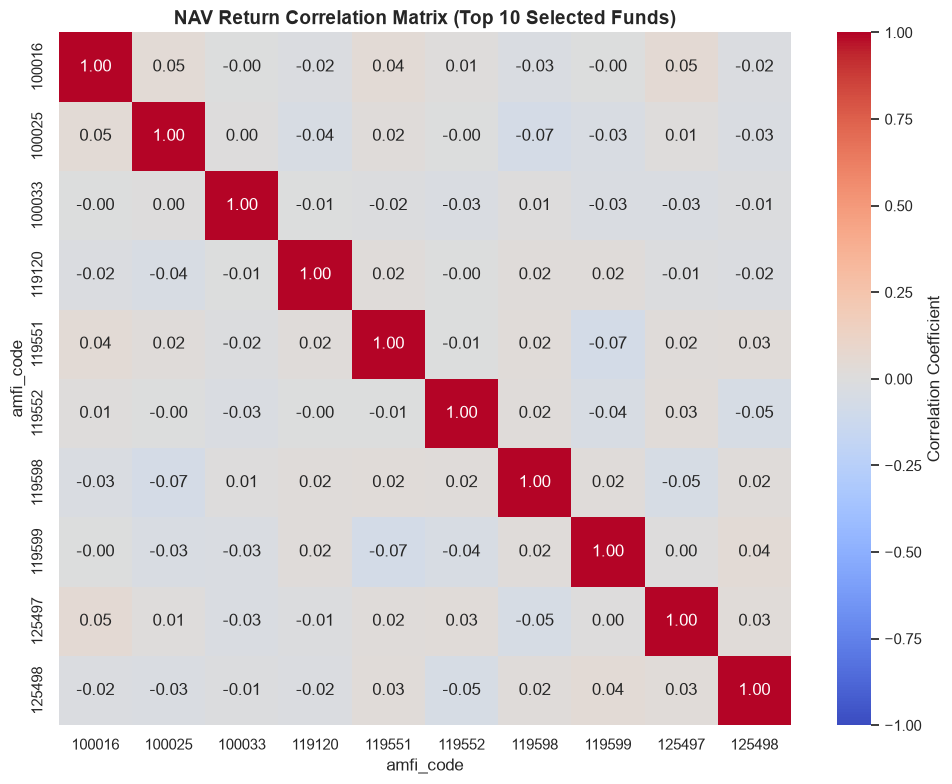

In [27]:
# Load NAV history dataset using the path discovered earlier
if csv_path is None:
	raise FileNotFoundError(
		"02_nav_history.csv was not found. Place it in the project folder."
	)

nav_history = pd.read_csv(csv_path)

# Ensure date is datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Select 10 unique schemes for correlation matrix
selected_schemes = (
    nav_history["amfi_code"]
    .drop_duplicates()
    .head(10)
    .tolist()
)
filtered_nav = nav_history[
	nav_history["amfi_code"].isin(selected_schemes)
]

# Pivot to get a wide dataframe where each column is a scheme's NAV
nav_pivot = filtered_nav.pivot(
	index="date",
	columns="amfi_code",
	values="nav",
)

# Compute daily returns
daily_returns = nav_pivot.pct_change(fill_method=None).dropna(how="all")

# Compute correlation matrix
corr_matrix = daily_returns.corr()

# Set up figure and plot heatmap
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")
sns.heatmap(
	corr_matrix,
	annot=True,
	cmap="coolwarm",
	fmt=".2f",
	vmin=-1,
	vmax=1,
	cbar_kws={"label": "Correlation Coefficient"},
)

plt.title(
	"NAV Return Correlation Matrix (Top 10 Selected Funds)",
	fontsize=14,
	weight="bold",
)
plt.tight_layout()
plt.savefig("exports/return_correlation_matrix.png", dpi=300)
plt.show()

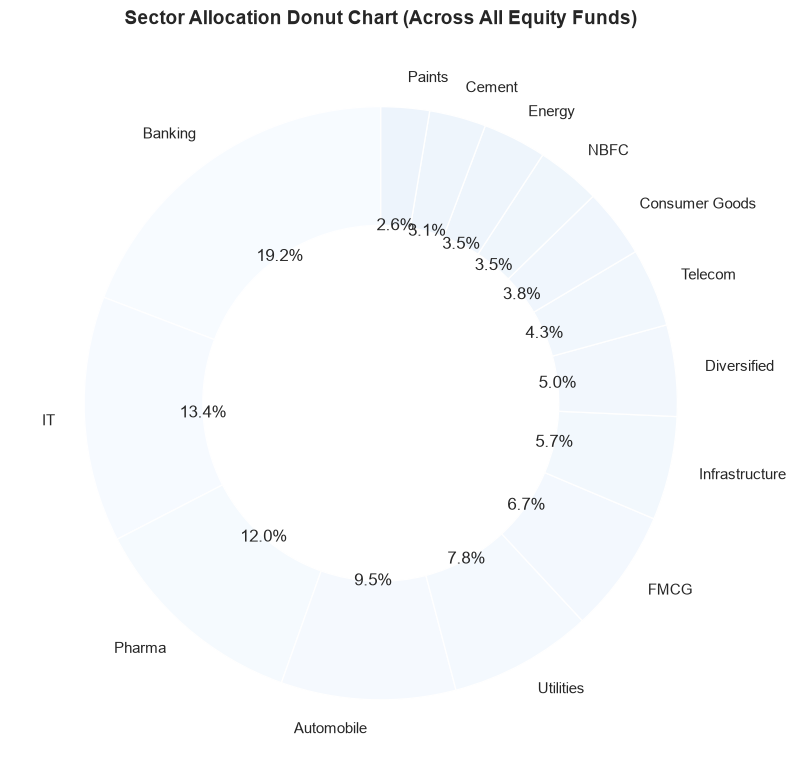

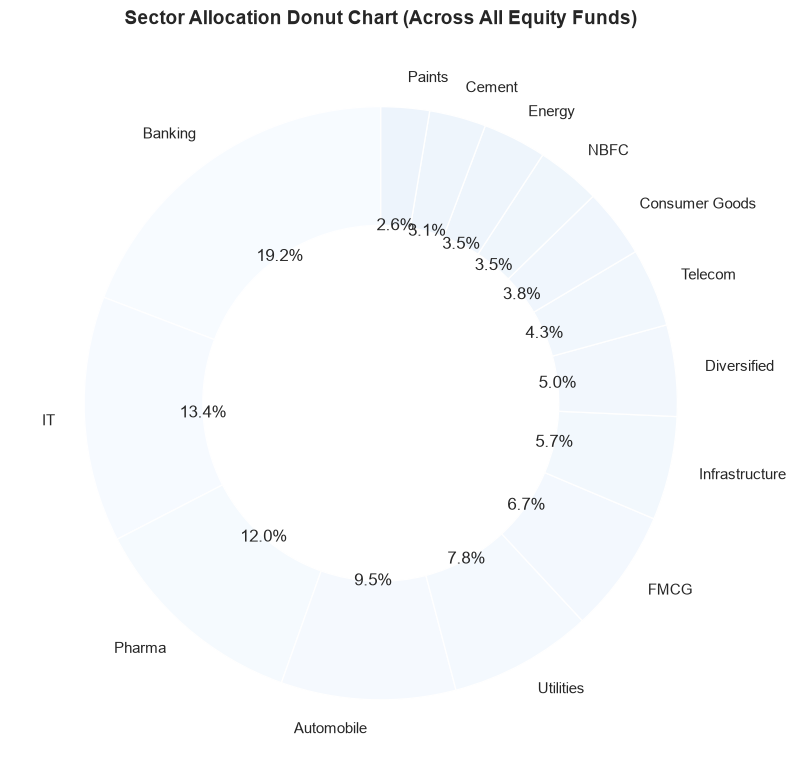

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load portfolio holdings dataset
# Load portfolio holdings dataset
holdings_path = next(
    (
        path
        for root in search_roots
        for path in root.rglob("09_portfolio_holdings.csv")
        if path.is_file()
    ),
    None,
)

if holdings_path is None:
    raise FileNotFoundError("09_portfolio_holdings.csv was not found.")

holdings = pd.read_csv(holdings_path)

# Aggregate sector weights
sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
    .sort_values(by="weight_pct", ascending=False)
)

# Set figure size and create donut chart
plt.figure(figsize=(10, 8))

# Convert NumPy colors to a list of valid Matplotlib color tuples
colors = [
    tuple(color)
    for color in plt.get_cmap("Blues")(
        range(len(sector_weights))
    )
]

plt.pie(
    sector_weights["weight_pct"].tolist(),
    labels=sector_weights["sector"].astype(str).tolist(),
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="w"),
)

plt.title(
    "Sector Allocation Donut Chart (Across All Equity Funds)",
    fontsize=14,
    weight="bold",
)
plt.tight_layout()
plt.savefig("exports/sector_allocation_donut.png", dpi=300)
plt.show()

# Filter for equity funds or aggregate sector weights across all equity holdings
sector_weights = holdings.groupby('sector')['weight_pct'].sum().reset_index().sort_values(by='weight_pct', ascending=False)

# Set figure size and create donut chart
plt.figure(figsize=(10, 8))
colors = [
    tuple(color)
    for color in plt.get_cmap("Blues")(range(len(sector_weights)))
]

plt.pie(
    sector_weights["weight_pct"].tolist(),
    labels=sector_weights["sector"].astype(str).tolist(),
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="w"),
)

plt.title('Sector Allocation Donut Chart (Across All Equity Funds)', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig("exports/sector_allocation_donut.png", dpi=300)
plt.show()

## 10 Key Exploratory Data Analysis (EDA) Findings

1. **NAV Trend Analysis:** Scheme NAVs demonstrated growth through 2022–2026, with variation across selected schemes. *(Ref: NAV trend chart)*

2. **AUM Growth and Concentration:** Industry AUM expanded substantially from 2022–2025, with SBI Mutual Fund among the largest contributors. *(Ref: `aum_growth.png`)*

3. **SIP Inflows Momentum:** Monthly SIP inflows increased significantly, reaching ₹31,002 crore in December 2025. *(Ref: SIP inflow chart)*

4. **Category Inflows Heatmap:** Liquid and sectoral/thematic categories recorded substantial inflows. *(Ref: `category_heatmap.png`)*

5. **Geographic Distribution:** SIP contributions varied across states, with both T30 and B30 cities contributing to investor activity. *(Ref: `geographic_distribution.png`)*

6. **Folio Count Growth:** Total industry folios increased from 13.26 crore in January 2022 to 26.12 crore in December 2025. *(Ref: `folio_count_growth.png`)*

7. **Return Correlation Matrix:** The selected schemes showed mostly weak correlations in the analyzed sample. *(Ref: `return_correlation_matrix.png`)*

8. **Sector Allocation Weights:** Banking, IT, and Pharma had the highest aggregated portfolio weights. *(Ref: `sector_allocation_donut.png`)*

9. **Fund-House AUM:** Fund-house AUM increased across the analyzed period, with SBI among the largest contributors. *(Ref: `aum_growth.png`)*

10. **Overall Summary:** The analysis shows expanding mutual-fund participation, increasing SIP activity, and continued growth in folios and assets.